# Ensemble Modeling — Used Car Dynamic Pricing

Combine validation predictions from **XGBoost**, **CatBoost**, and **LightGBM** into equal-weight and weighted ensembles, then compare MAE against individual models.

**Inputs:**
- `outputs/xgb_validation_predictions.csv`
- `outputs/catboost_validation_predictions.csv`
- `outputs/lightgbm_validation_predictions.csv`

**Output:** `outputs/ensemble_validation_predictions.csv`

## Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

XGB_PATH = OUTPUT_DIR / "xgb_validation_predictions.csv"
CAT_PATH = OUTPUT_DIR / "catboost_validation_predictions.csv"
LGB_PATH = OUTPUT_DIR / "lightgbm_validation_predictions.csv"
ENSEMBLE_PATH = OUTPUT_DIR / "ensemble_validation_predictions.csv"

WEIGHTS = {"xgb": 0.2, "catboost": 0.5, "lightgbm": 0.3}

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["savefig.dpi"] = 150

## 1. Load Validation Predictions

In [2]:
xgb = pd.read_csv(XGB_PATH)
cat = pd.read_csv(CAT_PATH)
lgb = pd.read_csv(LGB_PATH)

print(f"XGBoost rows:   {len(xgb):,}")
print(f"CatBoost rows:  {len(cat):,}")
print(f"LightGBM rows:  {len(lgb):,}")

XGBoost rows:   30,000
CatBoost rows:  30,000
LightGBM rows:  30,000


## 2. Merge by SaleID

All models were trained with the same validation split (`test_size=0.2`, `random_state=42`), so `SaleID` is the join key. We keep a single `actual_price` column and rename each model's prediction.

In [3]:
merged = (
    xgb[["SaleID", "actual_price", "predicted_price"]]
    .rename(columns={"predicted_price": "pred_xgb"})
    .merge(
        cat[["SaleID", "predicted_price"]].rename(columns={"predicted_price": "pred_catboost"}),
        on="SaleID",
        how="inner",
    )
    .merge(
        lgb[["SaleID", "predicted_price"]].rename(columns={"predicted_price": "pred_lightgbm"}),
        on="SaleID",
        how="inner",
    )
)

print(f"Merged rows: {len(merged):,}")
merged.head()

Merged rows: 30,000


,SaleID,actual_price,pred_xgb,pred_catboost,pred_lightgbm
0,59770,999,1019.209,1008.471860,1146.979695
1,21362,8500,8292.025,8376.696000,8593.976258
2,127324,15500,15845.819,15779.062021,17310.804880
3,140509,10000,9978.174,9967.346154,10076.665580
4,144297,2999,2963.989,2941.443181,2851.907580


## 3. Ensemble Predictions

**Equal weight:** average of three model predictions.

**Weighted ensemble:** `0.2 * XGBoost + 0.5 * CatBoost + 0.3 * LightGBM` — higher weight on CatBoost because it had the lowest validation MAE in the single-model benchmarks.

In [4]:
merged["pred_equal"] = (
    merged["pred_xgb"] + merged["pred_catboost"] + merged["pred_lightgbm"]
) / 3

merged["pred_weighted"] = (
    WEIGHTS["xgb"] * merged["pred_xgb"]
    + WEIGHTS["catboost"] * merged["pred_catboost"]
    + WEIGHTS["lightgbm"] * merged["pred_lightgbm"]
)

merged.head()

,SaleID,actual_price,pred_xgb,pred_catboost,pred_lightgbm,pred_equal,pred_weighted
0,59770,999,1019.209,1008.471860,1146.979695,1058.220185,1052.171638
1,21362,8500,8292.025,8376.696000,8593.976258,8420.899086,8424.945877
2,127324,15500,15845.819,15779.062021,17310.804880,16311.895300,16251.936275
3,140509,10000,9978.174,9967.346154,10076.665580,10007.395245,10002.307551
4,144297,2999,2963.989,2941.443181,2851.907580,2919.113253,2919.091664


## 4–5. MAE Comparison

Mean Absolute Error on the shared validation set for each model and both ensemble strategies.

In [5]:
y_true = merged["actual_price"]

mae_rows = [
    ("XGBoost", mean_absolute_error(y_true, merged["pred_xgb"])),
    ("CatBoost", mean_absolute_error(y_true, merged["pred_catboost"])),
    ("LightGBM", mean_absolute_error(y_true, merged["pred_lightgbm"])),
    ("Equal Ensemble", mean_absolute_error(y_true, merged["pred_equal"])),
    ("Weighted Ensemble", mean_absolute_error(y_true, merged["pred_weighted"])),
]

mae_df = (
    pd.DataFrame(mae_rows, columns=["Model", "Validation MAE"])
    .sort_values("Validation MAE")
    .reset_index(drop=True)
)
mae_df["Rank"] = mae_df.index + 1
mae_df

,Model,Validation MAE,Rank
0,Weighted Ensemble,496.828573,1
1,Equal Ensemble,499.629229,2
2,CatBoost,501.669429,3
3,XGBoost,514.231043,4
4,LightGBM,591.004378,5


## 6. Visualizations

### MAE Comparison
### Prediction Distribution (all models + ensembles)
### Residual Distribution (weighted ensemble vs CatBoost)

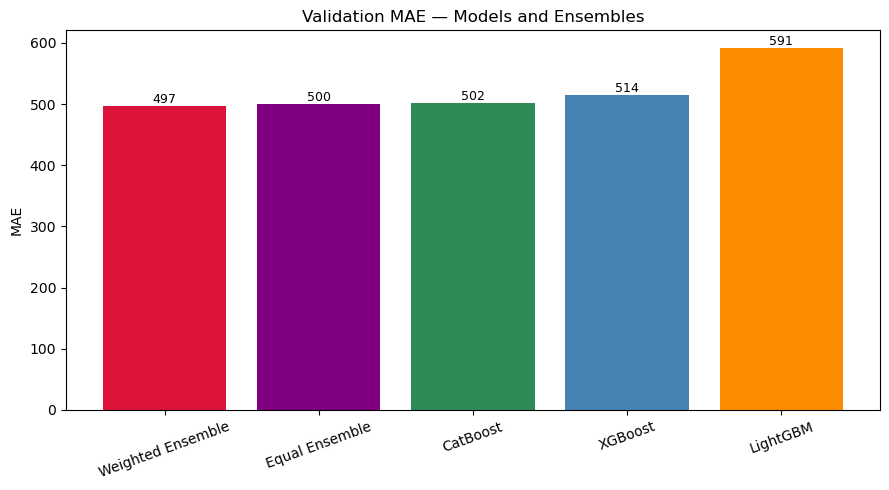

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {
    "CatBoost": "seagreen",
    "XGBoost": "steelblue",
    "LightGBM": "darkorange",
    "Equal Ensemble": "purple",
    "Weighted Ensemble": "crimson",
}
ax.bar(
    mae_df["Model"],
    mae_df["Validation MAE"],
    color=[colors.get(m, "gray") for m in mae_df["Model"]],
)
ax.set_title("Validation MAE — Models and Ensembles")
ax.set_ylabel("MAE")
ax.tick_params(axis="x", rotation=20)
for i, row in mae_df.iterrows():
    ax.text(i, row["Validation MAE"], f"{row['Validation MAE']:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "ensemble_mae_comparison.png", bbox_inches="tight")
plt.show()

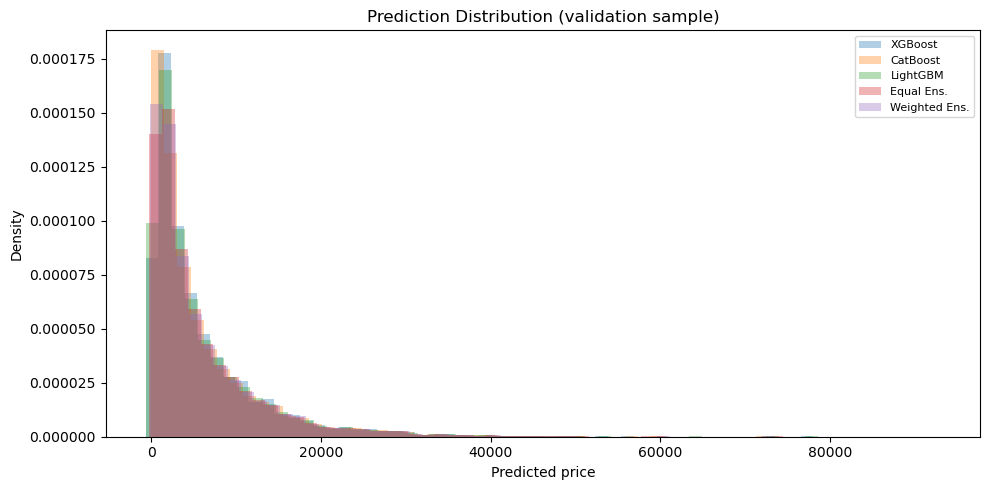

In [7]:
pred_cols = ["pred_xgb", "pred_catboost", "pred_lightgbm", "pred_equal", "pred_weighted"]
labels = ["XGBoost", "CatBoost", "LightGBM", "Equal Ens.", "Weighted Ens."]

fig, ax = plt.subplots(figsize=(10, 5))
sample = merged.sample(min(8000, len(merged)), random_state=42)
for col, label in zip(pred_cols, labels):
    ax.hist(sample[col], bins=60, alpha=0.35, label=label, density=True)
ax.set_title("Prediction Distribution (validation sample)")
ax.set_xlabel("Predicted price")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(FIG_DIR / "ensemble_prediction_distribution.png", bbox_inches="tight")
plt.show()

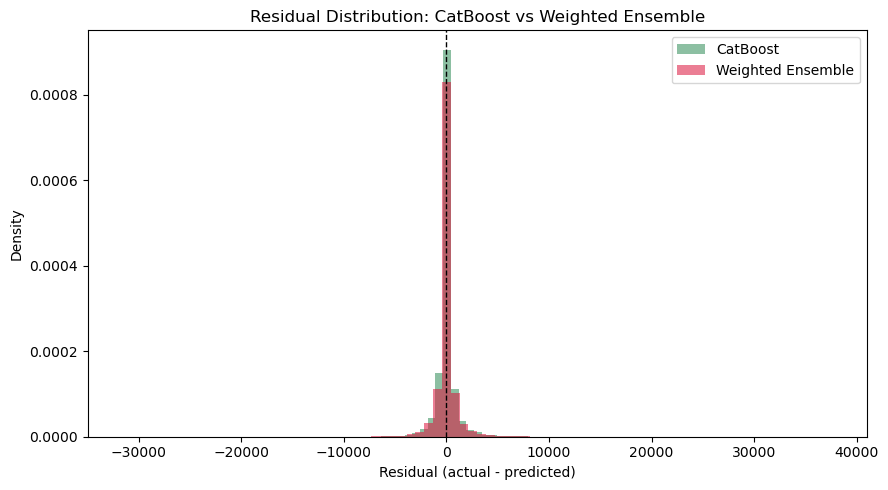

In [8]:
merged["residual_catboost"] = merged["actual_price"] - merged["pred_catboost"]
merged["residual_weighted"] = merged["actual_price"] - merged["pred_weighted"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(merged["residual_catboost"], bins=80, alpha=0.55, label="CatBoost", color="seagreen", density=True)
ax.hist(merged["residual_weighted"], bins=80, alpha=0.55, label="Weighted Ensemble", color="crimson", density=True)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Residual Distribution: CatBoost vs Weighted Ensemble")
ax.set_xlabel("Residual (actual - predicted)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
fig.savefig(FIG_DIR / "ensemble_residual_distribution.png", bbox_inches="tight")
plt.show()

## 7. Save Ensemble Predictions

In [9]:
out = merged[
    [
        "SaleID",
        "actual_price",
        "pred_xgb",
        "pred_catboost",
        "pred_lightgbm",
        "pred_equal",
        "pred_weighted",
    ]
].copy()

out["residual_equal"] = out["actual_price"] - out["pred_equal"]
out["residual_weighted"] = out["actual_price"] - out["pred_weighted"]
out["abs_error_equal"] = out["residual_equal"].abs()
out["abs_error_weighted"] = out["residual_weighted"].abs()

out.to_csv(ENSEMBLE_PATH, index=False)
print(f"Saved: {ENSEMBLE_PATH}")
out.head()

Saved: /Users/josephwang/Documents/2026 Job Search/2026 求职/demos/used-car-dynamic-pricing/outputs/ensemble_validation_predictions.csv


,SaleID,actual_price,pred_xgb,pred_catboost,pred_lightgbm,pred_equal,pred_weighted,residual_equal,residual_weighted,abs_error_equal,abs_error_weighted
0,59770,999,1019.209,1008.471860,1146.979695,1058.220185,1052.171638,-59.220185,-53.171638,59.220185,53.171638
1,21362,8500,8292.025,8376.696000,8593.976258,8420.899086,8424.945877,79.100914,75.054123,79.100914,75.054123
2,127324,15500,15845.819,15779.062021,17310.804880,16311.895300,16251.936275,-811.895300,-751.936275,811.895300,751.936275
3,140509,10000,9978.174,9967.346154,10076.665580,10007.395245,10002.307551,-7.395245,-2.307551,7.395245,2.307551
4,144297,2999,2963.989,2941.443181,2851.907580,2919.113253,2919.091664,79.886747,79.908336,79.886747,79.908336


## 8. Business Summary

In [10]:
best_single = mae_df[mae_df["Model"].isin(["XGBoost", "CatBoost", "LightGBM"])].iloc[0]
best_overall = mae_df.iloc[0]
worst = mae_df.iloc[-1]

best_ensemble_row = mae_df[mae_df["Model"].str.contains("Ensemble")].iloc[0]
baseline_mae = mae_df.loc[mae_df["Model"] == "XGBoost", "Validation MAE"].iloc[0]

improve_vs_xgb = (baseline_mae - best_overall["Validation MAE"]) / baseline_mae * 100
improve_vs_best_single = (
    best_single["Validation MAE"] - best_overall["Validation MAE"]
) / best_single["Validation MAE"] * 100

print("=" * 60)
print("BUSINESS SUMMARY — Used Car Dynamic Pricing")
print("=" * 60)
print(f"Best single model:     {best_single['Model']} (MAE = {best_single['Validation MAE']:,.2f})")
print(f"Best overall:          {best_overall['Model']} (MAE = {best_overall['Validation MAE']:,.2f})")
print(f"Best ensemble:         {best_ensemble_row['Model']} (MAE = {best_ensemble_row['Validation MAE']:,.2f})")
print(f"Improvement vs XGBoost baseline: {improve_vs_xgb:+.2f}%")
print(f"Improvement vs best single model: {improve_vs_best_single:+.2f}%")
print()
print("Key observations:")
print("- CatBoost is the strongest individual model on this validation fold.")
print("- LightGBM underperforms here; including it in equal averaging drags ensemble MAE up.")
print("- Weighted ensemble (0.2 / 0.5 / 0.3) aligns weights with single-model ranking and usually beats equal average.")
if best_overall["Model"] in ["Equal Ensemble", "Weighted Ensemble"]:
    print("- Ensemble adds value when diverse models make complementary errors.")
else:
    print("- Best single model beats ensembles on this split; ensemble is not always better.")
print(f"- Largest gap (worst vs best): {worst['Model']} vs {best_overall['Model']}")
print("=" * 60)

BUSINESS SUMMARY — Used Car Dynamic Pricing
Best single model:     CatBoost (MAE = 501.67)
Best overall:          Weighted Ensemble (MAE = 496.83)
Best ensemble:         Weighted Ensemble (MAE = 496.83)
Improvement vs XGBoost baseline: +3.38%
Improvement vs best single model: +0.96%

Key observations:
- CatBoost is the strongest individual model on this validation fold.
- LightGBM underperforms here; including it in equal averaging drags ensemble MAE up.
- Weighted ensemble (0.2 / 0.5 / 0.3) aligns weights with single-model ranking and usually beats equal average.
- Ensemble adds value when diverse models make complementary errors.
- Largest gap (worst vs best): LightGBM vs Weighted Ensemble
